# Trend Detection with DBSCAN
DBSCAN clustering on TF-IDF text embeddings to find trending sub-topics within the `trending_topics` dataset.

## 1. Imports & Config

In [3]:
import os
os.makedirs("Results/DBSCAN", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

from database_util import connect_database

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## 2. Load Data from PostgreSQL

In [4]:
conn = connect_database()

cursor = conn.cursor()
cursor.execute("""
    SELECT post_id, text_translated, niche, timestamp_utc, score, num_comments
    FROM final_trendingtopics
    WHERE text_translated IS NOT NULL
      AND TRIM(text_translated) != ''
""")
rows = cursor.fetchall()
cols = [desc[0] for desc in cursor.description]
df = pd.DataFrame(rows, columns=cols)
cursor.close()

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
df["score"] = df["score"].fillna(0)
df["num_comments"] = df["num_comments"].fillna(0)
df["engagement"] = df["score"] + df["num_comments"]

print(f"Loaded {len(df):,} rows")
print(df["niche"].value_counts())

Loaded 7,090 rows
niche
movies         1588
worldnews      1518
technology     1417
smartphones    1226
gaming          818
science         523
Name: count, dtype: int64


## 3. Text Vectorisation (TF-IDF → SVD)

In [5]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    stop_words="english"
)
X_tfidf = tfidf.fit_transform(df["text_translated"])
print(f"TF-IDF shape: {X_tfidf.shape}")

N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
X_norm = normalize(X_svd)
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")

TF-IDF shape: (7090, 8000)
SVD explained variance: 15.04%


## 4. Epsilon Tuning (k-distance plot)

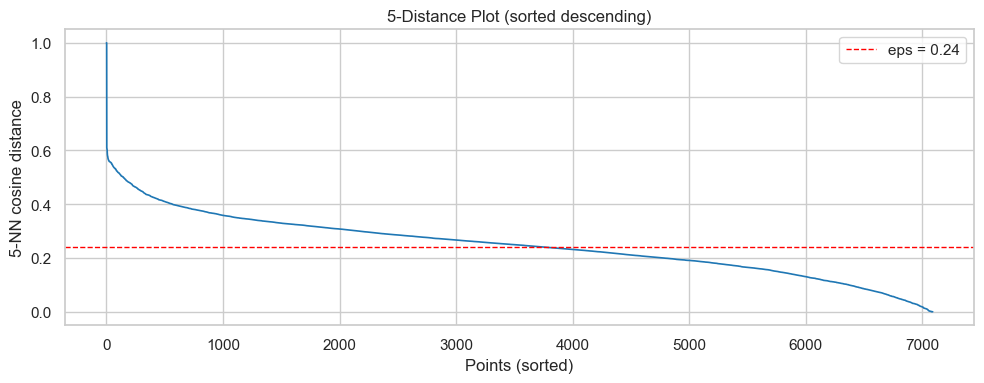

In [6]:
from sklearn.neighbors import NearestNeighbors

K = 5
nbrs = NearestNeighbors(n_neighbors=K, metric="cosine").fit(X_norm)
distances, _ = nbrs.kneighbors(X_norm)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, linewidth=1.2)
ax.set_title(f"{K}-Distance Plot (sorted descending)")
ax.set_xlabel("Points (sorted)")
ax.set_ylabel(f"{K}-NN cosine distance")
ax.axhline(0.24, color="red", linestyle="--", linewidth=1, label="eps = 0.24")
ax.legend()
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_k_distance.png", bbox_inches="tight")
plt.show()

## 5. DBSCAN Clustering
Adjust  EPS for clustering

In [7]:
EPS     = 0.1
MIN_PTS = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_PTS, metric="cosine", n_jobs=-1)
labels = dbscan.fit_predict(X_norm)

df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
noise_pct  = n_noise / len(labels) * 100

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({noise_pct:.1f}%)")
print(f"Clustered posts: {len(df) - n_noise:,}")

if n_clusters > 1:
    mask = labels != -1
    score = silhouette_score(X_norm[mask], labels[mask], metric="cosine", sample_size=3000)
    print(f"Silhouette score (excl. noise): {score:.4f}")

Clusters found : 78
Noise points   : 6,070 (85.6%)
Clustered posts: 1,020
Silhouette score (excl. noise): 0.7052


## 6. Cluster Sizes

C:\Users\rajib\AppData\Local\Temp\ipykernel_1340\3839870392.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_counts.head(top_n), x="cluster", y="count",


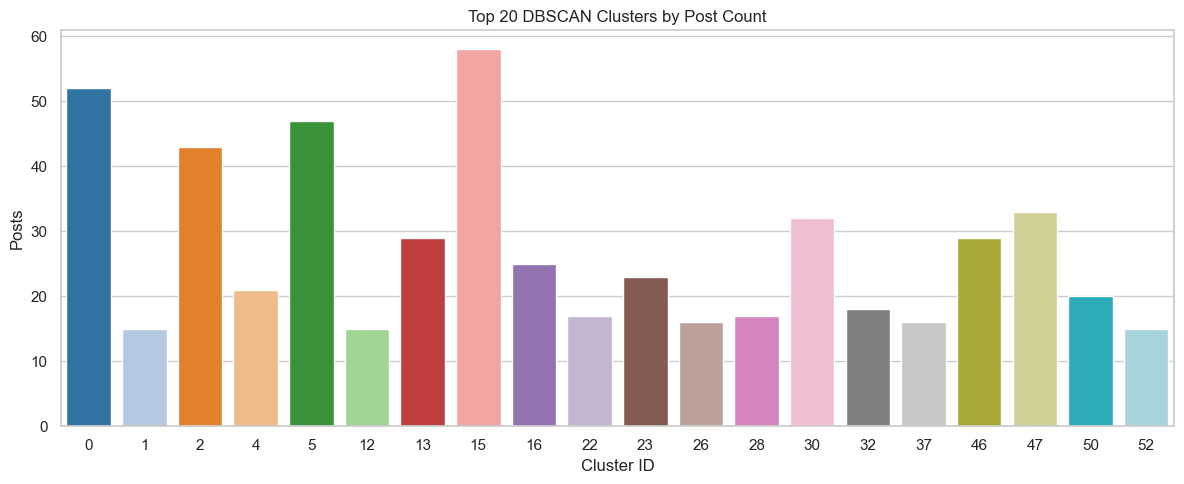

In [8]:
cluster_counts = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_n = min(20, len(cluster_counts))
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=cluster_counts.head(top_n), x="cluster", y="count",
            palette="tab20", ax=ax)
ax.set_title(f"Top {top_n} DBSCAN Clusters by Post Count")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_cluster_sizes.png", bbox_inches="tight")
plt.show()

## 7. Cluster Keywords (Top TF-IDF Terms)

In [9]:
feature_names = tfidf.get_feature_names_out()
TOP_K_WORDS = 8

print(f"{'Cluster':>8}  {'Posts':>6}  Top Keywords")
print("=" * 80)

cluster_keywords = {}
for cid in cluster_counts["cluster"]:
    mask = (df["cluster"] == cid).values
    centroid = X_tfidf[mask].mean(axis=0)
    centroid = np.asarray(centroid).flatten()
    top_idx  = centroid.argsort()[::-1][:TOP_K_WORDS]
    keywords = ", ".join(feature_names[top_idx])
    cluster_keywords[cid] = keywords
    n = mask.sum()
    print(f"{cid:>8}  {n:>6}  {keywords}")

df["cluster_keywords"] = df["cluster"].map(cluster_keywords)

 Cluster   Posts  Top Keywords
      15      58  trailer, official, official trailer, official teaser, teaser, theaters, june, 2026
       0      52  hormuz, strait, strait hormuz, iran, ships, says, blockade, trump
       5      47  ai, startup, wikipedia, hackers, banned, results, revenue, stock
       2      43  poster, official poster, official, starring, theaters, anniversary, horror, poster horror
      47      33  directed, scene directed, scene, 2018, starring, danny, andrew, 2013
      30      32  microsoft, windows, windows 11, 11, copilot, removing, update, tool
      46      29  social media, social, media, ban, media ban, kids, greece, teen
      13      29  study, study finds, finds, new study, heat, new, mortality, protect
      16      25  warner, warner bros, bros, paramount, paramount warner, merger, bros discovery, discovery
      23      23  china, sea, threat, tests, cables, philippines, depth, begin
       4      21  election, hungary, orbán, magyar, vance, orban,

## 8. Topic Distribution per Cluster

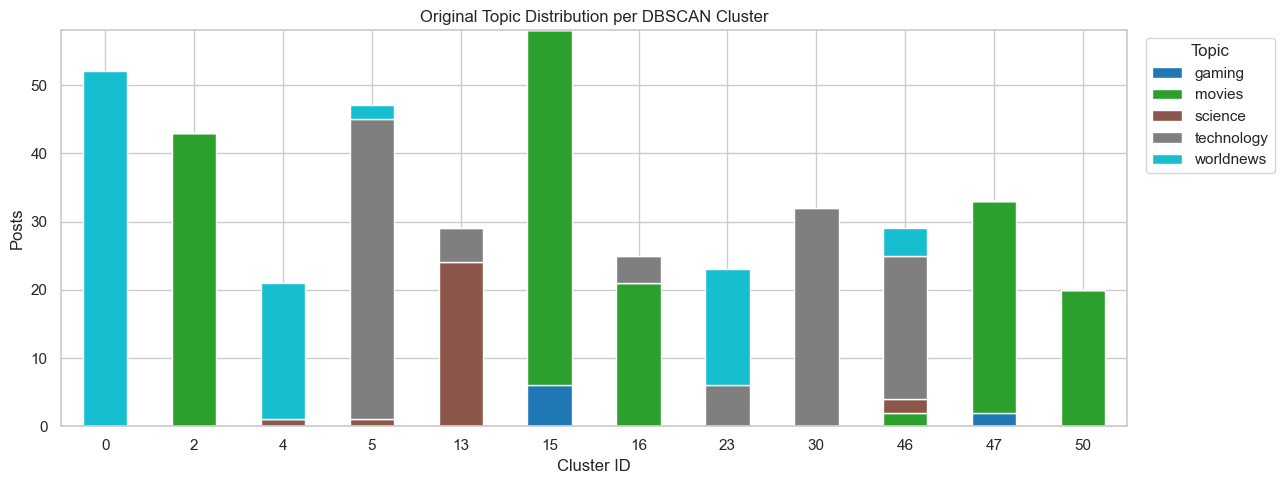

In [10]:
top_clusters = cluster_counts.head(12)["cluster"].tolist()
pivot = (
    df[df["cluster"].isin(top_clusters)]
    .groupby(["cluster", "niche"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind="bar", stacked=True, colormap="tab10", ax=ax)
ax.set_title("Original Topic Distribution per DBSCAN Cluster")
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Posts")
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_topic_distribution.png", bbox_inches="tight")
plt.show()

## 9. Engagement Analytics per Cluster

         Avg Engagement  Median     Total
cluster                                  
0                6734.1  2138.5  350175.0
4                8367.7  6123.0  175722.0
5                3051.0    47.0  143398.0
15               1640.0   128.0   95122.0
16               3262.5   454.0   81562.0
2                1658.3  1046.0   71305.0
13               2216.6   436.0   64280.0
30               1311.7   299.0   41975.0
23               1522.7   131.0   35022.0
47               1037.7   657.0   34243.0
46                733.7   212.0   21277.0
50                918.2   680.5   18364.0


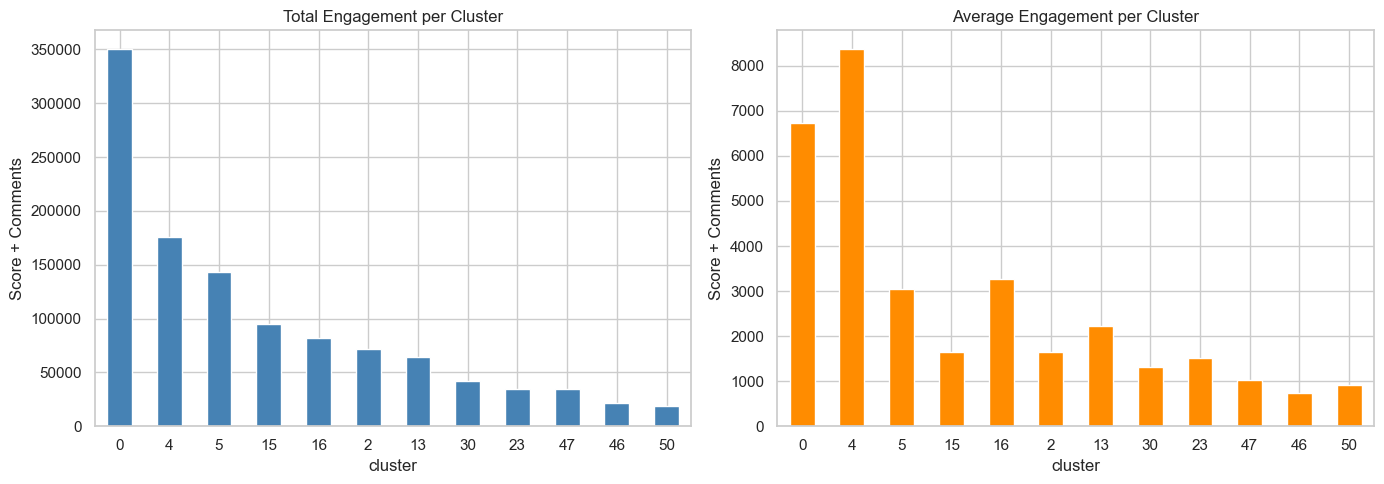

In [11]:
eng_stats = (
    df[df["cluster"].isin(top_clusters)]
    .groupby("cluster")["engagement"]
    .agg(["mean", "median", "sum"])
    .rename(columns={"mean": "Avg Engagement", "median": "Median", "sum": "Total"})
    .sort_values("Total", ascending=False)
)

print(eng_stats.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eng_stats["Total"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Engagement per Cluster")
axes[0].set_ylabel("Score + Comments")
axes[0].tick_params(axis="x", rotation=0)

eng_stats["Avg Engagement"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Average Engagement per Cluster")
axes[1].set_ylabel("Score + Comments")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_engagement.png", bbox_inches="tight")
plt.show()

## 10. Cluster Activity Over Time

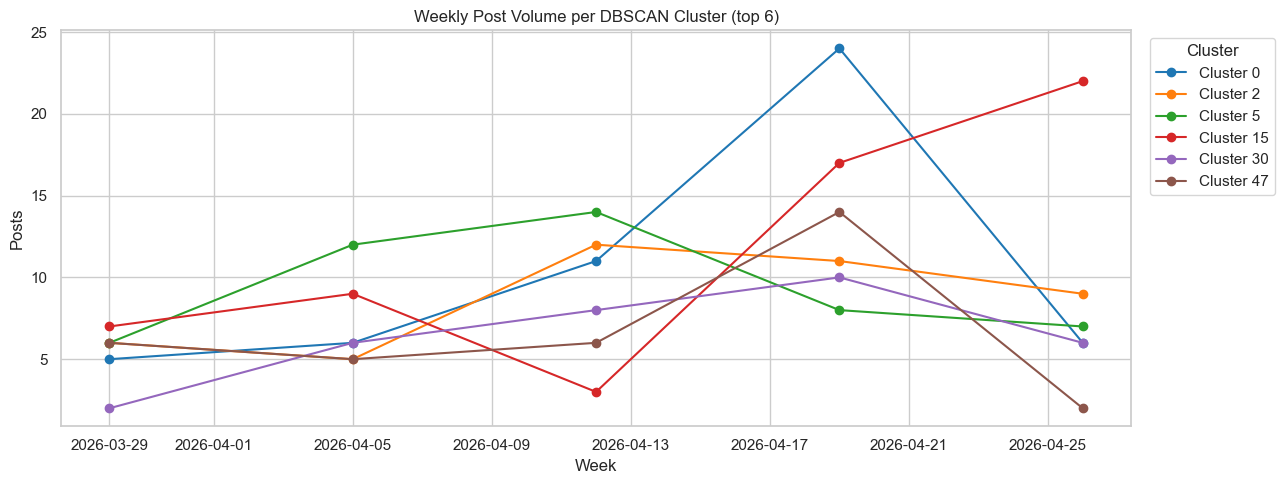

In [13]:
time_df = (
    df[df["cluster"].isin(top_clusters[:6])]
    .groupby([pd.Grouper(key="timestamp_utc", freq="W"), "cluster"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 5))
for cid, grp in time_df.groupby("cluster"):
    ax.plot(grp["timestamp_utc"], grp["count"], marker="o", label=f"Cluster {cid}")

ax.set_title("Weekly Post Volume per DBSCAN Cluster (top 6)")
ax.set_xlabel("Week")
ax.set_ylabel("Posts")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_time_series.png", bbox_inches="tight")
plt.show()

## 11. 2D Visualisation (SVD → 2 components)

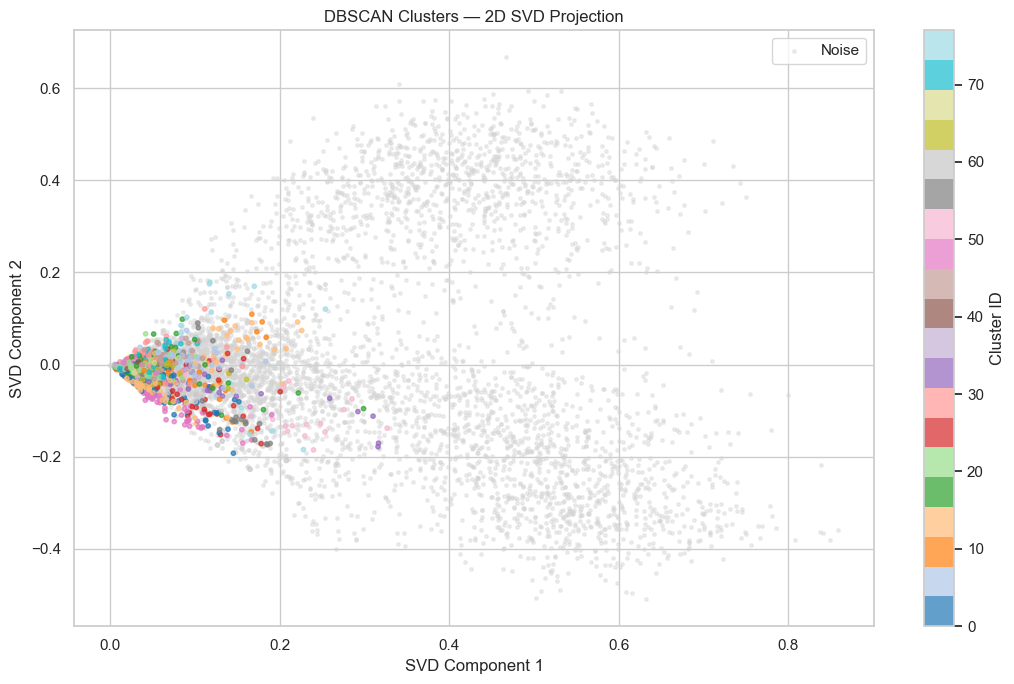

In [14]:
svd2 = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd2.fit_transform(X_norm)

plot_df = pd.DataFrame({"x": X_2d[:, 0], "y": X_2d[:, 1], "cluster": labels})

noise_mask   = plot_df["cluster"] == -1
cluster_mask = ~noise_mask

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(plot_df.loc[noise_mask, "x"], plot_df.loc[noise_mask, "y"],
           c="lightgrey", s=6, alpha=0.4, label="Noise")

scatter = ax.scatter(
    plot_df.loc[cluster_mask, "x"],
    plot_df.loc[cluster_mask, "y"],
    c=plot_df.loc[cluster_mask, "cluster"],
    cmap="tab20", s=10, alpha=0.7
)
plt.colorbar(scatter, ax=ax, label="Cluster ID")
ax.set_title("DBSCAN Clusters — 2D SVD Projection")
ax.set_xlabel("SVD Component 1")
ax.set_ylabel("SVD Component 2")
ax.legend()
plt.tight_layout()
plt.savefig("Results/DBSCAN/dbscan_2d.png", bbox_inches="tight")
plt.show()

## 12. Summary Table — Top Clusters

In [15]:
summary = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("post_id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("niche", lambda x: x.value_counts().index[0]),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("posts", ascending=False)
    .head(15)
)

summary["avg_engagement"] = summary["avg_engagement"].round(1)
summary["total_engagement"] = summary["total_engagement"].astype(int)

print("\n── DBSCAN Cluster Summary ──")
print(summary.to_string())


── DBSCAN Cluster Summary ──
         posts  avg_engagement  total_engagement dominant_topic                                                                                   keywords
cluster                                                                                                                                                   
15          58          1640.0             95122         movies         trailer, official, official trailer, official teaser, teaser, theaters, june, 2026
0           52          6734.1            350175      worldnews                          hormuz, strait, strait hormuz, iran, ships, says, blockade, trump
5           47          3051.0            143398     technology                           ai, startup, wikipedia, hackers, banned, results, revenue, stock
2           43          1658.3             71305         movies  poster, official poster, official, starring, theaters, anniversary, horror, poster horror
47          33          1037.7          

## 13. Trend Report

In [16]:
report = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .agg(
        posts=("post_id", "count"),
        avg_engagement=("engagement", "mean"),
        total_engagement=("engagement", "sum"),
        dominant_topic=("niche", lambda x: x.value_counts().index[0]),
        first_seen=("timestamp_utc", "min"),
        last_seen=("timestamp_utc", "max"),
        keywords=("cluster_keywords", "first")
    )
    .sort_values("total_engagement", ascending=False)
    .reset_index()
)

report["avg_engagement"] = report["avg_engagement"].round(1)
report["total_engagement"] = report["total_engagement"].astype(int)

print("=" * 80)
print("EMERGING TRENDS REPORT")
print("=" * 80)
for _, row in report.iterrows():
    print(f"\n#{int(row['cluster'])} | {row['dominant_topic']}")
    print(f"   Keywords   : {row['keywords']}")
    print(f"   Posts      : {row['posts']}  |  Total Engagement: {row['total_engagement']}  |  Avg: {row['avg_engagement']}")
    print(f"   Active     : {row['first_seen'].date()} → {row['last_seen'].date()}")
print("\n" + "=" * 80)

report.to_csv("Results/DBSCAN/trend_report_dbscan.csv", index=False)

EMERGING TRENDS REPORT

#0 | worldnews
   Keywords   : hormuz, strait, strait hormuz, iran, ships, says, blockade, trump
   Posts      : 52  |  Total Engagement: 350175  |  Avg: 6734.1
   Active     : 2026-03-26 → 2026-04-24

#4 | worldnews
   Keywords   : election, hungary, orbán, magyar, vance, orban, jd, prime
   Posts      : 21  |  Total Engagement: 175722  |  Avg: 8367.7
   Active     : 2026-04-02 → 2026-04-21

#5 | technology
   Keywords   : ai, startup, wikipedia, hackers, banned, results, revenue, stock
   Posts      : 47  |  Total Engagement: 143398  |  Avg: 3051.0
   Active     : 2026-03-25 → 2026-04-23

#40 | worldnews
   Keywords   : pope, pope leo, leo, africa, xiv, calls, exploitation, visit
   Posts      : 11  |  Total Engagement: 128970  |  Avg: 11724.5
   Active     : 2026-04-07 → 2026-04-23

#21 | technology
   Keywords   : sam altman, altman, sam, home, attack, man, ai, responds
   Posts      : 9  |  Total Engagement: 110905  |  Avg: 12322.8
   Active     : 2026-03-2